# Getting Started: Simulating Visibilities with `hera_sim`

This tutorial walks through a complete, realistic visibility simulation using the
unified simulation interface in `hera_sim.visibilities`. We will simulate the diffuse
radio sky — the Global Sky Model (GSM), via [pygdsm](https://github.com/telegraphic/pygdsm) —
as seen by a small, HERA-style hexagonal array, over a ~20 MHz sub-band and two hours
of LST.

We do this twice:

1. **[Part 1](#Part-1:-Simulating-interactively)** builds every ingredient directly in
   Python. This is the fastest way to explore and to iterate on a simulation.
2. **[Part 2](#Part-2:-Simulating-reproducibly-with-configuration-files)** writes the same
   simulation down as a set of configuration files, runs it from those files (both in
   Python and with the `hera-sim-vis.py` command-line script), and checks that we get
   *identical* visibilities. This is the way to run production simulations: the files
   are a complete record of what was simulated, and the command-line script can run as a
   batch job, e.g. on a cluster.

## The moving parts

Every visibility simulation needs three ingredients:

| Ingredient | What it describes | Object |
|---|---|---|
| Observation | Antenna positions, frequencies, times, polarizations | [pyuvdata.UVData](https://pyuvdata.readthedocs.io/en/latest/uvdata.html) |
| Sky | Brightness distribution of the sky (point sources or HEALPix maps) | [pyradiosky.SkyModel](https://pyradiosky.readthedocs.io/en/latest/skymodel.html) |
| Beams | Direction-dependent response of each antenna | [pyuvdata analytic beams](https://pyuvdata.readthedocs.io/en/latest/analytic_beam_tutorial.html) or [pyuvdata.UVBeam](https://pyuvdata.readthedocs.io/en/latest/uvbeam.html) |

`hera_sim` then adds three objects of its own:

- [ModelData](../reference/_autosummary/hera_sim.visibilities.simulators.rst) bundles the
  three ingredients together and checks that they are consistent.
- A [VisibilitySimulator](../reference/_autosummary/hera_sim.visibilities.simulators.rst)
  subclass does the actual maths. `hera_sim` wraps three: `MatVis`
  ([matvis](https://github.com/HERA-Team/matvis), direct matrix-based RIME evaluation),
  `FFTVis` ([fftvis](https://github.com/tyler-a-cox/fftvis), non-uniform FFT-based, often
  the fastest on CPU) and `UVSim` ([pyuvsim](https://github.com/RadioAstronomySoftwareGroup/pyuvsim),
  the slow-but-careful reference implementation).
- [VisibilitySimulation](../reference/_autosummary/hera_sim.visibilities.simulators.rst)
  combines a `ModelData` with a simulator, and runs it.

Because the simulators all sit behind the same interface, switching between them is a
one-line change.

## Requirements

You need `hera_sim` with its visibility-simulation extras, plus `pygdsm` for the sky
model:

```bash
pip install "hera_sim[vis]" pygdsm
```

The first time you use `pygdsm` it will download the GSM component maps, which are cached
for later use.

In [1]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import EarthLocation
from astropy.time import Time
from pygdsm import GlobalSkyModel
from pyradiosky import SkyModel
from pyuvdata import UVData

from hera_sim.antpos import hex_array
from hera_sim.beams import PolyBeam
from hera_sim.io import empty_uvdata
from hera_sim.visibilities import (
    FFTVis,
    ModelData,
    VisibilitySimulation,
    load_simulator_from_yaml,
)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
2026-10-06 21:16:43,253	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


# Part 1: Simulating interactively

## Choose the observation

Let's put every tunable number in one place.

A note on cost: the run time of the simulation scales roughly as
$N_{\rm times} \times N_{\rm freqs} \times N_{\rm pixels}$ (and, more weakly, with the number
of antennas). To keep this tutorial quick to run we use channels twice as wide as HERA's
native 122 kHz channels, and one sample every two minutes rather than HERA's ~10 seconds.
For a "real" simulation you would simply change these numbers — nothing else in the
tutorial depends on them.

In [2]:
# --- Array -----------------------------------------------------------------
HEX_NUM = 3  # antennas along each side of the hexagon -> 19 antennas
ANT_SEP = 14.6  # metres; the HERA dish spacing

# HERA's location as (latitude [deg], longitude [deg], altitude [m]).
HERA_LOCATION = (-30.72152612068957, 21.428303826863015, 1051.6900000218302)

# --- Frequencies: a ~20 MHz sub-band ---------------------------------------
START_FREQ = 150e6  # Hz
CHANNEL_WIDTH = 244140.625  # Hz (2x HERA's native channel width)
NFREQS = 82  # 82 x 244 kHz = 20.0 MHz

# --- Times: two hours of LST -------------------------------------------------
LST_START = 1.0  # hours. LST ~ 1-3 h is the coldest part of the sky seen by HERA.
INTEGRATION_TIME = 120.0  # seconds
NTIMES = 60  # 60 x 2 min = 2 hours

# --- Sky model resolution ----------------------------------------------------
NSIDE = 64  # HEALPix resolution: ~0.9 degree pixels

## The antenna array

`hera_sim.antpos` has helpers for building common array layouts. `hex_array` builds a
HERA-like hexagonal array. By default it mimics HERA's full design (the core is split into
three offset sections, and outrigger antennas are added); here we turn those features off
to get a simple, compact, 19-element hexagon.

The result is a dictionary mapping antenna number to its East-North-Up (ENU) position in
metres, which is the format the rest of `hera_sim` expects.

Number of antennas: 19


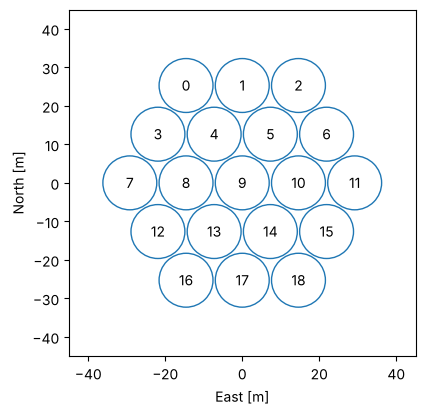

In [3]:
antpos = hex_array(HEX_NUM, sep=ANT_SEP, split_core=False, outriggers=0)
print(f"Number of antennas: {len(antpos)}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
for ant, (e, n, _) in antpos.items():
    ax.add_patch(plt.Circle((e, n), radius=7, fc="none", ec="C0"))
    ax.text(e, n, str(ant), ha="center", va="center")
ax.set_xlim(-45, 45)
ax.set_ylim(-45, 45)
ax.set_aspect("equal")
ax.set_xlabel("East [m]")
ax.set_ylabel("North [m]");

## Observation times from LST

For a drift-scan telescope like HERA, what matters is the **local sidereal time** (LST),
which sets which part of the sky is overhead. Simulators, however, need actual times
(Julian dates). The function below finds the first Julian date after a given date at
which the LST at HERA equals the LST we want.

We round the result to five decimal places (< 1 second). This isn't necessary, but it
means the start time is a number that is easy to write into a configuration file in
Part 2 — and still reproduces the simulation *exactly*.

In [4]:
lat, lon, alt = HERA_LOCATION
hera_site = EarthLocation.from_geodetic(lat=lat * u.deg, lon=lon * u.deg, height=alt * u.m)


def jd_at_lst(lst_hours: float, date: str = "2025-10-01") -> float:
    "Return the first Julian date after ``date`` at which the LST at HERA is ``lst_hours``."
    t0 = Time(date, scale="utc", location=hera_site)
    lst0 = t0.sidereal_time("apparent").hour
    # Convert the required number of sidereal hours into solar hours.
    dt = ((lst_hours - lst0) % 24) / 1.0027379093
    return (t0 + dt * u.hour).jd


START_JD = round(jd_at_lst(LST_START), 5)
print(f"Start time: JD {START_JD}  ({Time(START_JD, format='jd').isot} UTC)")

Start time: JD 2460950.45181  (2025-10-01T22:50:36.384 UTC)


## The observation: an empty `UVData` object

`hera_sim.io.empty_uvdata` creates a `UVData` object with all the metadata of our
observation, and visibilities that are all zero. It's a thin wrapper around
`pyuvsim.simsetup.initialize_uvdata_from_keywords`,
and any extra keyword arguments are passed through to it.

A few things worth pointing out:

- We only ask for the `xx` polarization. Our sky model is unpolarized and so is the
  beam model we'll use below, so this is all we need (see the end of the tutorial for
  polarized simulations).
- `conjugation_convention="ant1<ant2"` and the feed/mount information aren't strictly
  required, but specifying them silences some warnings from `pyuvsim` about defaults.
- The data includes autocorrelations, and every antenna pair, which is what `MatVis`
  requires (`FFTVis` is more flexible).

In [5]:
uvdata = empty_uvdata(
    array_layout=antpos,
    telescope_location=HERA_LOCATION,
    Nfreqs=NFREQS,
    start_freq=START_FREQ,
    channel_width=CHANNEL_WIDTH,
    Ntimes=NTIMES,
    start_time=START_JD,
    integration_time=INTEGRATION_TIME,
    polarization_array=["xx"],
    conjugation_convention="ant1<ant2",
    mount_type="fixed",
    feed_array=["x", "y"],
    feed_angle=[np.pi / 2, 0],
)

lsts_hours = np.unique(uvdata.lst_array) * 12 / np.pi
print(f"Antennas    : {uvdata.Nants_data}")
print(f"Baselines   : {uvdata.Nbls} (including autos)")
print(f"Frequencies : {uvdata.Nfreqs} channels, "
      f"{uvdata.freq_array.min() / 1e6:.2f} - {uvdata.freq_array.max() / 1e6:.2f} MHz")
print(f"Times       : {uvdata.Ntimes} integrations, "
      f"LST {lsts_hours.min():.3f} - {lsts_hours.max():.3f} h")

Antennas    : 19
Baselines   : 190 (including autos)
Frequencies : 82 channels, 150.00 - 169.78 MHz
Times       : 60 integrations, LST 1.000 - 2.972 h


## The beam

`hera_sim.beams` provides analytic models of the HERA antenna response. `PolyBeam`
describes an azimuthally symmetric beam using a Chebyshev polynomial in zenith angle, with
a power-law scaling of the beam width with frequency.
`PolyBeam.like_fagnoni19()` gives coefficients fit to the electromagnetic simulations of
the HERA dish by [Fagnoni et al. (2021)](https://arxiv.org/abs/1908.02383).

Beams are `pyuvdata` `AnalyticBeam` objects, so they can be evaluated directly. Note that
a beam represents the response of a *single antenna*; the per-baseline "primary beam" is
the product of the two antennas' responses.

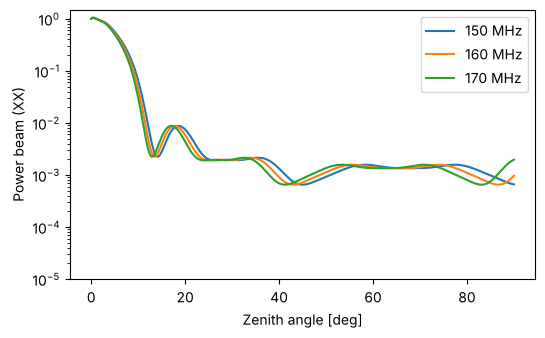

In [6]:
beam = PolyBeam.like_fagnoni19()

za = np.linspace(0, np.pi / 2, 300)
plot_freqs = np.array([150e6, 160e6, 170e6])
# power_eval returns shape (Naxes_vec=1, Npols, Nfreqs, Npositions).
power = beam.power_eval(az_array=np.zeros_like(za), za_array=za, freq_array=plot_freqs)

fig, ax = plt.subplots(figsize=(6, 3.5))
for i, f in enumerate(plot_freqs):
    ax.semilogy(np.degrees(za), power[0, 0, i].real, label=f"{f / 1e6:.0f} MHz")
ax.set_xlabel("Zenith angle [deg]")
ax.set_ylabel("Power beam (XX)")
ax.set_ylim(1e-5, 1.5)
ax.legend();

## The sky: the Global Sky Model

`pygdsm`'s `GlobalSkyModel` (de Oliveira-Costa et al. 2008) generates full-sky HEALPix
maps of the diffuse sky brightness temperature at any frequency, at `NSIDE=512`. We generate
one map per frequency channel and immediately degrade it to our working resolution. (Doing
it one channel at a time keeps the memory use down: 82 maps at `NSIDE=512` would take
2 GB.)

**How fine should `NSIDE` be?** The simulators treat each pixel as a point source at the
pixel centre, so the pixels need to be small compared to the finest fringe on the sky,
$\lambda / b_{\rm max}$. For our longest baseline (58 m) at 170 MHz that's about 1.7°,
while `NSIDE=64` pixels are 0.9° across: just about adequate for a demonstration. For
science-quality simulations, or longer baselines, use a larger `NSIDE` (at a cost
proportional to the number of pixels).

GSM maps: (82, 49152) (Nfreqs, Npix), in Kelvin


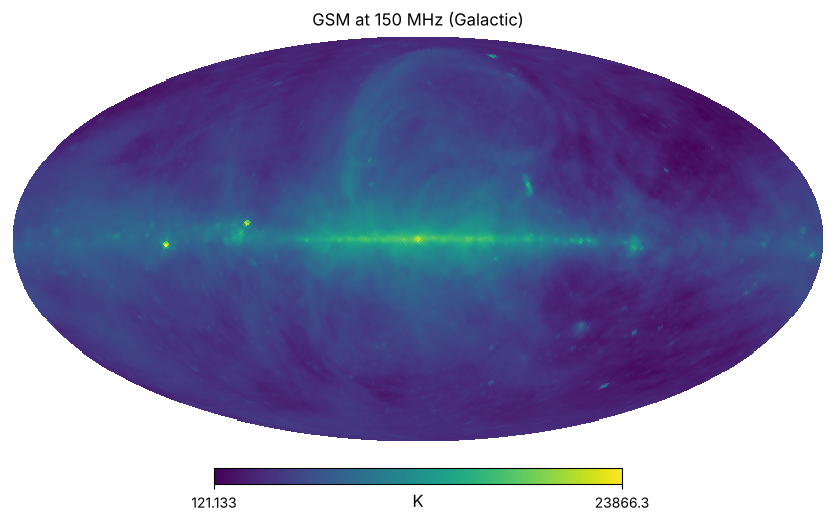

In [7]:
freqs = uvdata.freq_array  # use *exactly* the frequencies of the observation
gsm = GlobalSkyModel(freq_unit="Hz")
gsm_maps = np.array([hp.ud_grade(gsm.generate(f), NSIDE) for f in freqs])
print(f"GSM maps: {gsm_maps.shape} (Nfreqs, Npix), in Kelvin")

hp.mollview(
    gsm_maps[0], norm="log", unit="K", title=f"GSM at {freqs[0] / 1e6:.0f} MHz (Galactic)"
)

Now we wrap the maps in a `pyradiosky.SkyModel`. The Stokes array has shape
`(4, Nfreqs, Ncomponents)` for (I, Q, U, V); the GSM is unpolarized so only Stokes I is
non-zero. Since we have a map at every frequency, the `spectral_type` is `"full"`.

The GSM comes in Galactic coordinates, but the simulators work in equatorial (ICRS)
coordinates, so we interpolate the map onto an ICRS HEALPix grid with
`healpix_interp_transform`.

You can leave the map in brightness temperature (K): when the simulator converts the
HEALPix map to point sources, `pyradiosky` converts each pixel to a flux density in Jy
using the pixel solid angle.

In [8]:
npix = hp.nside2npix(NSIDE)
stokes = np.zeros((4, NFREQS, npix)) * u.K
stokes[0] = gsm_maps * u.K

sky = SkyModel(
    component_type="healpix",
    nside=NSIDE,
    hpx_order="ring",
    hpx_inds=np.arange(npix),
    stokes=stokes,
    spectral_type="full",
    freq_array=freqs * u.Hz,
    frame="galactic",
    history="GSM2008 from pygdsm, degraded to NSIDE=64.",
)
sky.healpix_interp_transform("icrs", full_sky=True)
print(f"Sky model: {sky.Ncomponents} {sky.component_type} components in the {sky.frame} frame")

Sky model: 49152 healpix components in the icrs frame


Let's see what part of the sky we're observing. The track of the zenith over our LST range
(at declination = HERA's latitude, and RA = LST) is shown in white — a long way from the
Galactic plane.

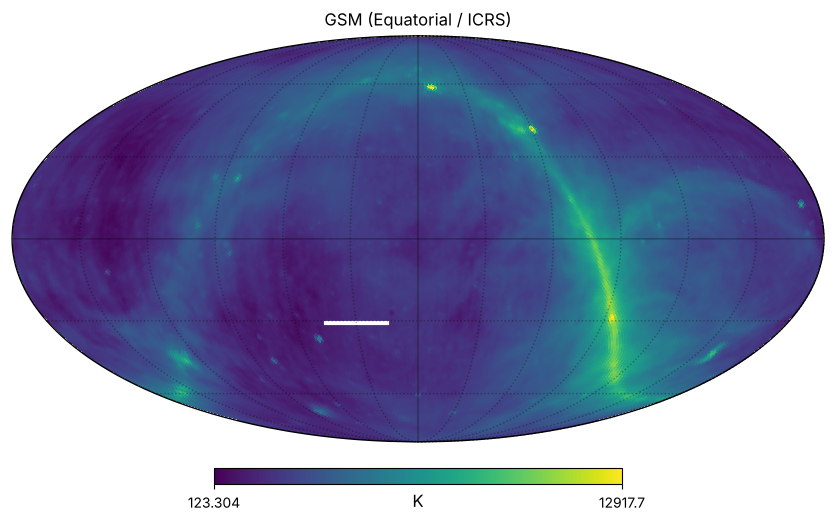

In [9]:
icrs_map = np.zeros(npix)
icrs_map[sky.hpx_inds] = sky.stokes[0, 0].value
hp.mollview(icrs_map, norm="log", unit="K", title="GSM (Equatorial / ICRS)")
hp.projplot(lsts_hours * 15, np.full_like(lsts_hours, lat), "w-", lw=3, lonlat=True)
hp.graticule(dpar=30, dmer=30, alpha=0.3)

Building the sky model is often the slowest part of setting up a simulation, so it's a good
idea to save it. We'll also need it on disk for Part 2. `skyh5` is `pyradiosky`'s native
HDF5 format.

In [10]:
sim_dir = Path("gsm_sim")
sim_dir.mkdir(exist_ok=True)
sky.write_skyh5(sim_dir / "gsm_nside64.skyh5", clobber=True)

## Running the simulation

Now we combine the observation, sky and beam into a `ModelData` object. `beams` takes a
list of beams; with a single beam, every antenna uses it. (To give antennas different beams,
pass several beams plus a `beam_ids` list saying which antenna uses which.)

Then we choose a simulator — here `FFTVis` — and hand both to a `VisibilitySimulation`.

In [11]:
data_model = ModelData(uvdata=uvdata, sky_model=sky, beams=[beam])

simulation = VisibilitySimulation(data_model=data_model, simulator=FFTVis())

Calling `simulate()` runs the simulation. The visibilities are written into
`simulation.uvdata.data_array` (`simulation.uvdata` is the very same `UVData` object we
passed in, now filled in).

This takes about three minutes on a 4-core laptop (including a few seconds of
just-in-time compilation the first time a simulator is used).

To use a different simulator, all you'd change is the `simulator` argument above, e.g.
`MatVis()` (which agrees with `FFTVis` to high precision, but is slower here) or
`UVSim()`.

> **Note:** to save memory, `VisibilitySimulation` modifies the `ModelData` in place: e.g.
> the HEALPix sky model is converted to point sources, and the baseline-time axis of the
> `UVData` may be re-ordered to suit the simulator. If you want to keep the original
> objects, pass in copies.

In [12]:
%%time
simulation.simulate();

CPU times: user 6min 45s, sys: 5.69 s, total: 6min 50s
Wall time: 2min 59s


## Looking at the results

The result is an ordinary `UVData` object, so all of `pyuvdata`'s tools work on it. Let's
look at an autocorrelation and three different baselines:

In [13]:
uvd = simulation.uvdata
lsts = np.unique(uvd.lst_array) * 12 / np.pi  # hours
freqs_mhz = uvd.freq_array / 1e6

baselines = {
    "Auto (0, 0)": (0, 0),
    "14.6 m E-W (0, 1)": (0, 1),
    "58.4 m E-W (7, 11)": (7, 11),
    "50.6 m N-S (0, 16)": (0, 16),
}
for name, (a1, a2) in baselines.items():
    e, n, _ = antpos[a2] - antpos[a1]
    print(f"{name:20s}: E = {e:6.1f} m, N = {n:6.1f} m")

Auto (0, 0)         : E =    0.0 m, N =    0.0 m
14.6 m E-W (0, 1)   : E =   14.6 m, N =    0.0 m
58.4 m E-W (7, 11)  : E =   58.4 m, N =    0.0 m
50.6 m N-S (0, 16)  : E =    0.0 m, N =  -50.6 m


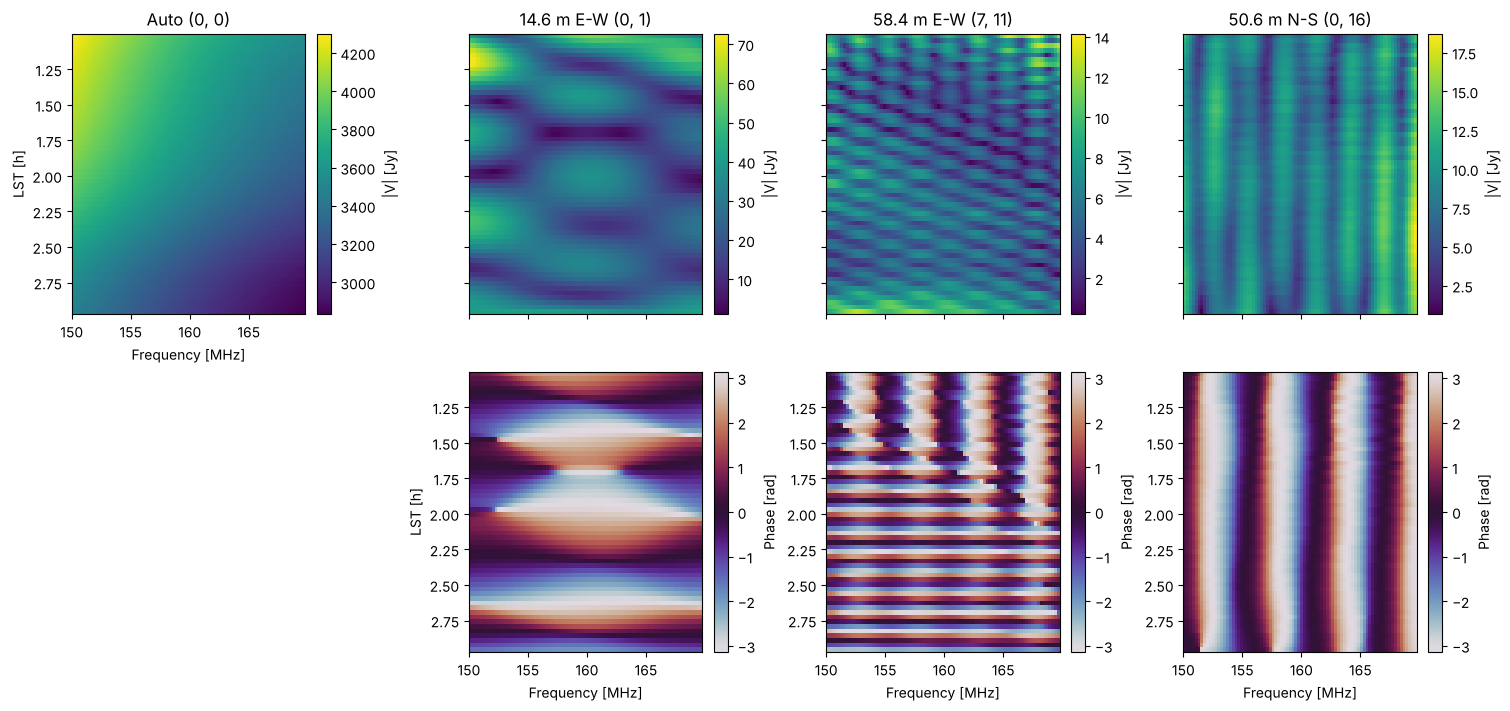

In [14]:
extent = [freqs_mhz[0], freqs_mhz[-1], lsts[-1], lsts[0]]
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True, layout="constrained")

for i, (name, bl) in enumerate(baselines.items()):
    vis = uvd.get_data(bl + ("xx",))  # shape (Ntimes, Nfreqs)
    im = axes[0, i].imshow(np.abs(vis), aspect="auto", extent=extent, interpolation="none")
    fig.colorbar(im, ax=axes[0, i], label="|V| [Jy]")
    axes[0, i].set_title(name)
    axes[1, i].set_xlabel("Frequency [MHz]")
    if bl[0] == bl[1]:
        # Autocorrelations are real, so their phase is just round-off noise.
        axes[1, i].set_axis_off()
        axes[0, i].tick_params(labelbottom=True)
        axes[0, i].set_xlabel("Frequency [MHz]")
        continue
    im = axes[1, i].imshow(
        np.angle(vis), aspect="auto", extent=extent, cmap="twilight", interpolation="none"
    )
    fig.colorbar(im, ax=axes[1, i], label="Phase [rad]")
    axes[1, i].tick_params(labelleft=True)
axes[0, 0].set_ylabel("LST [h]")
axes[1, 1].set_ylabel("LST [h]");

The autocorrelation (which is purely real, so we don't show its phase) is a smooth,
slowly-changing power law. On the cross-correlations,
the phase winds faster with frequency on the longer E-W baseline, and changes faster with
time on E-W baselines than on N-S baselines, as the sky drifts east to west.

One important property of smooth-spectrum foregrounds like these, and the reason HERA
can hope to find the much fainter 21 cm signal underneath them, is that they are confined
to low *delays* (the Fourier dual of frequency): no further than the light-travel time
along the baseline (the "horizon limit"). Let's check that with a quick delay transform
(a Fourier transform over frequency, with a Blackman window to suppress leakage from the
edges of the band):

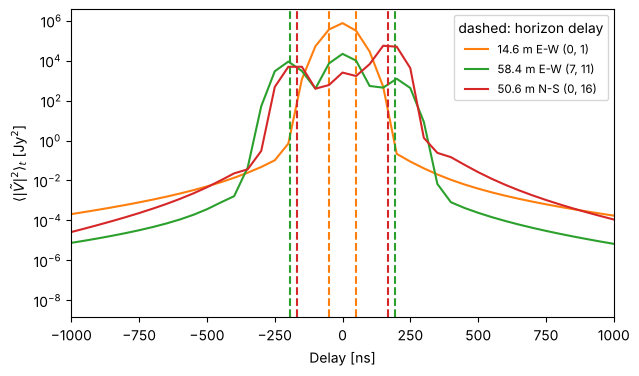

In [15]:
window = np.blackman(uvd.Nfreqs)
delays = np.fft.fftshift(np.fft.fftfreq(uvd.Nfreqs, d=CHANNEL_WIDTH)) * 1e9  # ns

fig, ax = plt.subplots(figsize=(7, 4))
for i, (name, bl) in enumerate(list(baselines.items())[1:], start=1):
    vis = uvd.get_data(bl + ("xx",))
    dspec = np.fft.fftshift(np.fft.fft(vis * window, axis=1), axes=1)
    ax.semilogy(delays, np.mean(np.abs(dspec) ** 2, axis=0), color=f"C{i}", label=name)
    blen = np.linalg.norm(antpos[bl[1]] - antpos[bl[0]])
    horizon = blen / 2.998e8 * 1e9  # ns
    ax.axvline(horizon, color=f"C{i}", ls="--")
    ax.axvline(-horizon, color=f"C{i}", ls="--")
ax.set_xlabel("Delay [ns]")
ax.set_ylabel(r"$\langle |\tilde{V}|^2 \rangle_t$ [Jy$^2$]")
ax.set_xlim(-1000, 1000)
ax.legend(title="dashed: horizon delay", fontsize="small");

The emission is indeed concentrated inside the horizon delays (dashed lines). The
peaks *at* the horizon on the two longer baselines are the well-known "pitchfork": bright
diffuse emission close to the horizon, where the baseline's projected length is largest.
The power just beyond the horizon is leakage from the frequency structure of the beam and the
finite bandwidth.

Finally, we can write the simulation to disk in any format `pyuvdata` supports, e.g. UVH5.

By default `pyuvdata` checks that autocorrelations are real before writing. Floating-point
round-off in the simulator leaves them with tiny imaginary parts (about $10^{-15}$ of the real
part), so we pass `fix_autos=True` to zero those out.

In [16]:
uvd.write_uvh5(sim_dir / "gsm_hera19_interactive.uvh5", clobber=True, fix_autos=True)

Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 9.884187994645026e-12, largest imaginary/real ratio was 2.5027572760493027e-15.


# Part 2: Simulating reproducibly with configuration files

Building a simulation interactively is great for exploring, but for "production" simulations
we want something better:

- a complete, human-readable **record** of exactly what was simulated, that can be shared,
  version-controlled, and re-run months later;
- the ability to run large simulations as a **script** — on a cluster, and in parallel with
  MPI — rather than in a notebook.

`hera_sim` does this using the configuration-file format of
[pyuvsim](https://pyuvsim.readthedocs.io/en/latest/parameter_files.html) (which means the
same files will also work directly with `pyuvsim`). A simulation is described by:

1. a **sky model** file (we saved one above);
2. an **antenna layout** CSV file;
3. a **telescope configuration** YAML file: telescope name, location, and beam models;
4. an **"obsparam"** YAML file: the top-level file, specifying the frequencies, times and
   polarizations, pointing to the three files above, and saying where to write the output;
5. a **simulator configuration** YAML file (specific to `hera_sim`): which simulator to
   use, and its options.

All relative paths inside the obsparam file are interpreted relative to the obsparam file
itself, so we keep everything together in the `gsm_sim/` directory.

## The antenna layout

The layout file is a whitespace-separated table with columns for the antenna name, number,
beam ID (an index into the list of beams in the telescope configuration) and ENU position in
metres. It's easiest to write it from our `antpos` dictionary:

In [17]:
with open(sim_dir / "hera19_layout.csv", "w") as fl:
    fl.write("Name\tNumber\tBeamID\tE\tN\tU\n")
    for ant, (e, n, up) in antpos.items():
        # Default float formatting is the shortest string that reproduces the number
        # exactly, so the positions in the file are identical to those in `antpos`.
        fl.write(f"{ant}\t{ant}\t0\t{e}\t{n}\t{up}\n")

print((sim_dir / "hera19_layout.csv").read_text())

Name	Number	BeamID	E	N	U
0	0	0	-14.6	25.287941790505606	0.0
1	1	0	0.0	25.287941790505606	0.0
2	2	0	14.6	25.287941790505606	0.0
3	3	0	-21.9	12.643970895252803	0.0
4	4	0	-7.3	12.643970895252803	0.0
5	5	0	7.3	12.643970895252803	0.0
6	6	0	21.9	12.643970895252803	0.0
7	7	0	-29.2	0.0	0.0
8	8	0	-14.6	0.0	0.0
9	9	0	0.0	0.0	0.0
10	10	0	14.6	0.0	0.0
11	11	0	29.2	0.0	0.0
12	12	0	-21.9	-12.643970895252803	0.0
13	13	0	-7.3	-12.643970895252803	0.0
14	14	0	7.3	-12.643970895252803	0.0
15	15	0	21.9	-12.643970895252803	0.0
16	16	0	-14.6	-25.287941790505606	0.0
17	17	0	0.0	-25.287941790505606	0.0
18	18	0	14.6	-25.287941790505606	0.0



## The telescope configuration

This contains the telescope's name and location (latitude, longitude, altitude), and the
beams. Each entry under `beam_paths` is either a path to a beam file readable by
`pyuvdata.UVBeam` (e.g. a beamfits file), or — as here — an analytic beam, marked with the
`!AnalyticBeam` tag. `class` can be a beam class from `pyuvdata` (e.g. `AiryBeam`,
`GaussianBeam`) or the full import path of any `AnalyticBeam` subclass, such as
`hera_sim.beams.PolyBeam`; the remaining entries are passed to that class's constructor.
Here, they are the same parameters that `PolyBeam.like_fagnoni19()` used above.

> **Watch out:** YAML reads numbers like `1.0e8` as *strings* (it needs `1.0e+8`), so it's
> safest to write numbers out in full.

In [18]:
%%writefile gsm_sim/telescope_config.yaml
telescope_name: hera_sim
telescope_location: (-30.72152612068957, 21.428303826863015, 1051.6900000218302)
beam_paths:
  0: !AnalyticBeam
    class: hera_sim.beams.PolyBeam
    ref_freq: 100000000.0
    spectral_index: -0.6975
    beam_coeffs: [
      0.29778665, -0.44821433, 0.27338272, -0.10030698, -0.01195859, 0.06063853,
      -0.04593295, 0.0107879, 0.01390283, -0.01881641, -0.00177106, 0.01265177,
      -0.00568299, -0.00333975, 0.00452368, 0.00151808, -0.00593812, 0.00351559,
    ]

Writing gsm_sim/telescope_config.yaml


## The obsparam file

This is the top-level file. Its sections specify:

- `filing`: where to write the output (used by the command-line script). Note that `outdir`
  is relative to the directory you run the script *from*.
- `freq` and `time`: the frequency channels and observation times. Several equivalent
  parametrizations are allowed (e.g. `bandwidth` or `end_freq` instead of `Nfreqs`; see the
  [pyuvsim docs](https://pyuvsim.readthedocs.io/en/latest/parameter_files.html)). We use
  the same numbers as in Part 1, including the rounded start time.
- `polarization_array`: the polarizations to simulate, as integer codes (-5 is `xx`).
- `telescope`: paths to the antenna layout and telescope configuration.
- `sources`: the sky model. This can be a `skyh5` file as here, but also e.g. a GLEAM
  VOTable or a text catalog of point sources.
- `ordering`: the baseline conjugation convention and the ordering of the
  baseline-time axis.

In [19]:
%%writefile gsm_sim/obsparam.yaml
filing:
  outdir: gsm_sim
  outfile_name: gsm_hera19_cli
  output_format: uvh5
  clobber: true
freq:
  start_freq: 150000000.0
  channel_width: 244140.625
  Nfreqs: 82
time:
  start_time: 2460950.45181
  integration_time: 120.0
  Ntimes: 60
polarization_array: [-5]
telescope:
  array_layout: hera19_layout.csv
  telescope_config_name: telescope_config.yaml
sources:
  catalog: gsm_nside64.skyh5
ordering:
  conjugation_convention: ant1<ant2
  blt_order: [time, baseline]

Writing gsm_sim/obsparam.yaml


(If you've changed the parameters at the top of Part 1, make sure to change them here too!)

## The simulator configuration

Finally, the simulator configuration chooses the simulator by name — one of the built-in
simulators (`MatVis`, `FFTVis` or `UVSim`) or the full import path of your own
`VisibilitySimulator` subclass — and gives any arguments for its constructor (see the API
documentation for each simulator for the options).

In [20]:
%%writefile gsm_sim/fftvis.yaml
simulator: FFTVis
precision: 2

Writing gsm_sim/fftvis.yaml


## Running from the configuration files in Python

`ModelData.from_config` reads the obsparam file (and everything it points to), and
`load_simulator_from_yaml` creates the simulator. After that, everything is the same as in
Part 1. This is also a handy way to *start* an interactive session: load a configuration, then
tweak the objects before simulating.

In [21]:
data_model_cfg = ModelData.from_config(sim_dir / "obsparam.yaml")
simulator_cfg = load_simulator_from_yaml(sim_dir / "fftvis.yaml")

simulation_cfg = VisibilitySimulation(data_model=data_model_cfg, simulator=simulator_cfg)
simulation_cfg.simulate()
uvd_cfg = simulation_cfg.uvdata

Let's check that we've reproduced Part 1. (The only difference we expect is tiny: we zeroed
the $\sim 10^{-11}$ Jy imaginary parts of the Part 1 autocorrelations before writing them to
disk.) We compare baseline by baseline (rather
than comparing the raw `data_array`s), since the ordering of the baseline-time axis isn't
guaranteed to be the same.

In [22]:
def max_difference(uvd1: UVData, uvd2: UVData) -> float:
    "Maximum absolute difference between the xx visibilities in two UVData objects."
    assert set(uvd1.get_antpairs()) == set(uvd2.get_antpairs())
    assert np.allclose(np.unique(uvd1.time_array), np.unique(uvd2.time_array), rtol=0, atol=1e-9)
    assert np.allclose(uvd1.freq_array, uvd2.freq_array)
    return max(
        np.max(np.abs(uvd1.get_data(ap + ("xx",)) - uvd2.get_data(ap + ("xx",))))
        for ap in uvd1.get_antpairs()
    )


diff = max_difference(uvd, uvd_cfg)
print(f"Max |V_interactive - V_config| = {diff:.2e} Jy  (max |V| = {np.abs(uvd.data_array).max():.0f} Jy)")
assert diff < 1e-6

Max |V_interactive - V_config| = 9.88e-12 Jy  (max |V| = 4300 Jy)


## Running from the command line

For large simulations you'll want to run outside of Python/Jupyter altogether.
`hera_sim` installs the `hera-sim-vis.py` script, which takes the obsparam file and the
simulator configuration, runs the simulation, and writes the result to the location given in
the `filing` section of the obsparam file. It has a few useful extra options (run
`hera-sim-vis.py --help` to see them), for example `--dry-run` to check the configuration
and estimate memory use without simulating, `--compress` to only keep one baseline
from each redundant group in the output, and `--run-auto-check --fix_autos` to make the
autocorrelations exactly real (as we did by hand above).

On a single machine, `FFTVis` and `MatVis` already make use of multiple cores. To spread a
simulation over many machines with MPI, use the `UVSim` simulator (i.e. `simulator: UVSim`
in the simulator configuration), which is parallelized with MPI by `pyuvsim`:

```bash
mpirun -n 64 hera-sim-vis.py gsm_sim/obsparam.yaml gsm_sim/uvsim.yaml
```

(`MatVis` and `FFTVis` can also split frequencies across MPI processes, but currently only
when constructed in Python with an `mpi_comm` argument — not from the configuration file.)

Here we run it in serial from the notebook (the `!` runs a shell command). By default the
script logs its progress in detail; we set `--log-level WARNING` to keep the output short.

In [23]:
!hera-sim-vis.py gsm_sim/obsparam.yaml gsm_sim/fftvis.yaml --log-level WARNING

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ hera-sim-vis: Simulating Visibilities                                                                                                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯



────────────────────────────────────────────────────────────────── Simulation Configuration: ───────────────────────────────────────────────────────────────────


filing:
  clobber: true
  outdir: gsm_sim
  outfile_name: gsm_hera19_cli
  output_format: uvh5
freq:
  Nfreqs: 82
  channel_width: 244140.625
  start_freq: 150000000.0
ordering:
  blt_order:
  - time
  - baseline
  conjugation_convention: ant1<ant2
polarization_array:
- -5
sources:
  catalog: gsm_nside64.skyh5
telescope:
  array_layout: hera19_layout.csv
  telescope_config_name: telescope_config.yaml
time:
  Ntimes: 60
  integration_time: 120.0
  start_time: 2460950.45181

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Using FFTVis Simulator

Using the following packages:

        pyuvdata: 3.2.6
        pyuvsim: 1.4.2
        pyradiosky: 1.1.1
        hera_sim: 0.1.dev216+g6ea338ca5.d20261006
        FFTVis: 1.0.0

─────────────────────────────────────────────────────────────── Important Simulation Parameters ───────────────────────────────────────────────────────────────

 This simulation will use at least 0.09GB of RAM (Available: 13.61GB).


────────────────────────────────────────────────────────────────────── Running Simulation ──────────────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Complete!


In [24]:
uvd_cli = UVData.from_file(sim_dir / "gsm_hera19_cli.uvh5")
diff = max_difference(uvd, uvd_cli)
print(f"Max |V_interactive - V_cli| = {diff:.2e} Jy")
assert diff < 1e-6

Max |V_interactive - V_cli| = 0.00e+00 Jy


Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 9.884187994645026e-12, largest imaginary/real ratio was 2.5027572760493027e-15.


All three routes give the same visibilities. 🎉

# Where to go from here

- **Polarization.** Use a polarized beam, e.g. `PolyBeam.like_fagnoni19(polarized=True)`
  (or a `UVBeam` E-field beam), and request all four linear polarizations
  (`polarization_array=["xx", "xy", "yx", "yy"]`, or `[-5, -7, -8, -6]` in the obsparam).
- **Point sources.** Add a catalog of point sources such as GLEAM. `pyradiosky` can read the
  GLEAM VOTable (`SkyModel.from_file(..., filetype="gleam")`) or point at it from the
  obsparam (`sources: {catalog: gleam.vot}`). Point-source and diffuse models can be combined
  with `SkyModel.concat` after converting the diffuse model with `healpix_to_point()`.
- **Realistic beams.** Swap the `PolyBeam` for a simulated beam file, read as a
  `pyuvdata.UVBeam` (or given as a path under `beam_paths` in the telescope configuration).
- **Instrumental effects.** The simulated `UVData` object is the natural input to
  `hera_sim.Simulator`, which adds noise, gains, crosstalk, RFI and other systematics. See
  the [Simulator tutorial](hera_sim_simulator.ipynb) and the
  [end-to-end example](end_to_end_example.ipynb).
- **More detail.** See the [visibility simulator tutorial](visibility_simulator.ipynb) for
  more on the `SkyModel` object, and on writing your own `VisibilitySimulator`.